# CC3092 · Hoja de trabajo #2 — Transformers y mecanismos de atención

**Nombre:** Renato Rojas **Carné:** 23813


In [1]:
import math, os, time, warnings
import numpy as np
import pandas as pd
import torch, torch.nn as nn, torch.nn.functional as F
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore", category=UserWarning)
torch.manual_seed(0); np.random.seed(0)

device = "cuda" if torch.cuda.is_available() else "cpu"
os.makedirs("figures", exist_ok=True)
os.makedirs("results", exist_ok=True)
plt.rcParams.update({"figure.dpi": 110, "savefig.bbox": "tight", "axes.grid": False})

def save(name):
    plt.savefig(f"figures/{name}.png", dpi=160)
    plt.show()

print("torch", torch.__version__, "| device:", device)

torch 2.14.1+cu126 | device: cuda


## Parte A — Verificaciones numéricas de la sección 3

### A.1 Varianza de `q·k` y efecto del escalamiento


In [2]:
def var_qk(d_k, n=20_000):
    q, k = torch.randn(n, d_k), torch.randn(n, d_k)
    return (q * k).sum(-1).var().item()

dims = [4, 16, 64, 256, 1024]
tabla_var = pd.DataFrame({
    "d_k": dims,
    "Var(q·k) empírica": [var_qk(d) for d in dims],
    "Var teórica (= d_k)": dims,
})
tabla_var["Var(q·k/√d_k)"] = tabla_var["Var(q·k) empírica"] / tabla_var["d_k"]
tabla_var.round(3)

,d_k,Var(q·k) empírica,Var teórica (= d_k),Var(q·k/√d_k)
0,4,3.975,4,0.994
1,16,16.071,16,1.004
2,64,64.249,64,1.004
3,256,253.065,256,0.989
4,1024,1015.562,1024,0.992


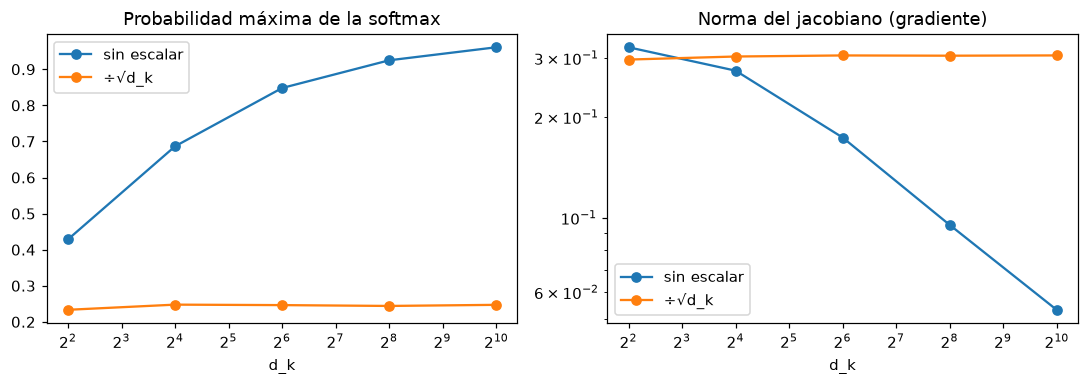

,d_k,escalado,p_max media,||J_softmax||_F
0,4,False,0.4288,0.3232
1,4,True,0.2334,0.2971
2,16,False,0.6866,0.2752
3,16,True,0.2477,0.3034
4,64,False,0.8480,0.1738
5,64,True,0.2464,0.3056
6,256,False,0.9248,0.0953
7,256,True,0.2441,0.3051
8,1024,False,0.9609,0.0532
9,1024,True,0.2472,0.3057


In [ ]:
def softmax_stats(d_k, n_keys=16, trials=2000, scale=True):
    q = torch.randn(trials, 1, d_k); K = torch.randn(trials, n_keys, d_k)
    z = (q @ K.transpose(1, 2)).squeeze(1)
    if scale:
        z = z / math.sqrt(d_k)
    p = z.softmax(-1)
    J = torch.diag_embed(p) - p.unsqueeze(-1) * p.unsqueeze(-2)      
    return p.max(-1).values.mean().item(), J.flatten(1).norm(dim=1).mean().item()

rows = []
for d in dims:
    for sc in (False, True):
        pmax, jn = softmax_stats(d, scale=sc)
        rows.append({"d_k": d, "escalado": sc, "p_max media": pmax, "||J_softmax||_F": jn})
sm = pd.DataFrame(rows)

fig, ax = plt.subplots(1, 2, figsize=(10, 3.6))
for sc, lab in ((False, "sin escalar"), (True, "÷√d_k")):
    s = sm[sm.escalado == sc]
    ax[0].plot(s.d_k, s["p_max media"], "o-", label=lab)
    ax[1].plot(s.d_k, s["||J_softmax||_F"], "o-", label=lab)
for a, t in zip(ax, ["Probabilidad máxima de la softmax", "Norma del jacobiano (gradiente)"]):
    a.set_xscale("log", base=2); a.set_xlabel("d_k"); a.set_title(t); a.legend()
ax[1].set_yscale("log")
plt.tight_layout(); save("A1_softmax_saturacion")
sm.round(4)

Resultado: la varianza empírica de $q\cdot k$ coincide con $d_k$ (tabla anterior) y la de $q\cdot k/\sqrt{d_k}$ queda ≈ 1.
Sin escalar, la desviación estándar de los logits crece como $\sqrt{d_k}$: la probabilidad máxima de la softmax pasa de 0.43 ($d_k=4$) a 0.96 ($d_k=1024$),
y la norma del jacobiano $\mathrm{diag}(p)-pp^\top$ cae de 0.32 a 0.05 (los gradientes se desvanecen). Con $1/\sqrt{d_k}$ ambas magnitudes son constantes (≈ 0.25 y ≈ 0.30) para cualquier $d_k$.

### A.2 Multi-head: ¿cambia el número de parámetros?

In [4]:
d_model = 512
for h in (1, 2, 4, 8, 16):
    mha = nn.MultiheadAttention(d_model, h, batch_first=True)
    n_par = sum(p.numel() for p in mha.parameters())
    print(f"h={h:2d} | d_k=d_model/h={d_model//h:3d} | parámetros = {n_par:,}")
print("4·d_model² + 4·d_model (sesgos) =", 4 * d_model**2 + 4 * d_model)

h= 1 | d_k=d_model/h=512 | parámetros = 1,050,624
h= 2 | d_k=d_model/h=256 | parámetros = 1,050,624
h= 4 | d_k=d_model/h=128 | parámetros = 1,050,624
h= 8 | d_k=d_model/h= 64 | parámetros = 1,050,624
h=16 | d_k=d_model/h= 32 | parámetros = 1,050,624
4·d_model² + 4·d_model (sesgos) = 1050624


### A.3 Self-attention es equivariante a permutaciones (no conoce el orden)

Sin codificación posicional, permutar los tokens de entrada solo permuta la salida: $\mathrm{SA}(PX)=P\,\mathrm{SA}(X)$.

In [5]:
mha = nn.MultiheadAttention(64, 8, batch_first=True).eval()
x = torch.randn(1, 10, 64)
perm = torch.randperm(10)
with torch.no_grad():
    y, _ = mha(x, x, x)
    y_perm, _ = mha(x[:, perm], x[:, perm], x[:, perm])
print("max |SA(PX) - P·SA(X)| =", (y_perm - y[:, perm]).abs().max().item())

max |SA(PX) - P·SA(X)| = 8.940696716308594e-08


### A.4 Codificación posicional sinusoidal

Propiedad: $PE_{pos}\cdot PE_{pos+k}$ depende solo de $k$ (distancia relativa), no de $pos$.

PE[p]·PE[p+5] para p = 0, 10, 50: [47.185, 47.185, 47.185]


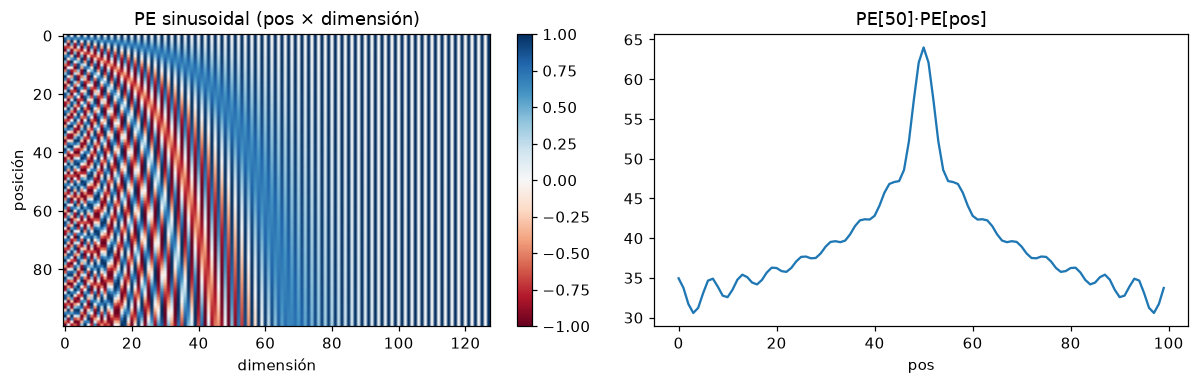

In [6]:
def sinusoidal_pe(n, d):
    pos = torch.arange(n).unsqueeze(1).float()
    i = torch.arange(0, d, 2).float()
    ang = pos / (10000 ** (i / d))
    pe = torch.zeros(n, d)
    pe[:, 0::2], pe[:, 1::2] = torch.sin(ang), torch.cos(ang)
    return pe

pe = sinusoidal_pe(100, 128)
k = 5
print("PE[p]·PE[p+5] para p = 0, 10, 50:", [round((pe[p] @ pe[p + k]).item(), 4) for p in (0, 10, 50)])

fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
im = ax[0].imshow(pe.numpy(), aspect="auto", cmap="RdBu"); ax[0].set_title("PE sinusoidal (pos × dimensión)")
ax[0].set_xlabel("dimensión"); ax[0].set_ylabel("posición"); plt.colorbar(im, ax=ax[0])
ax[1].plot((pe @ pe.T)[50].numpy()); ax[1].set_title("PE[50]·PE[pos]"); ax[1].set_xlabel("pos")
plt.tight_layout(); save("A4_positional_encoding")

## Parte B — Atención en PyTorch (sección 4)

### B.1 `F.scaled_dot_product_attention` vs implementación manual


In [ ]:
B, H, L, E = 2, 4, 6, 16
q, k, v = (torch.randn(B, H, L, E) for _ in range(3))

def manual_attn(q, k, v, causal=False):
    s = q @ k.transpose(-2, -1) / math.sqrt(q.size(-1))
    if causal:
        bloqueo = torch.triu(torch.ones(q.size(-2), k.size(-2), dtype=torch.bool), diagonal=1)
        s = s.masked_fill(bloqueo, float("-inf"))
    return s.softmax(-1) @ v

for causal in (False, True):
    ref = manual_attn(q, k, v, causal)
    out = F.scaled_dot_product_attention(q, k, v, is_causal=causal)
    print(f"is_causal={causal!s:5} -> coincide con la versión manual:", torch.allclose(ref, out, atol=1e-5))

# máscara booleana en SDPA: True = participa
keep = torch.tril(torch.ones(L, L, dtype=torch.bool))
out_mask = F.scaled_dot_product_attention(q, k, v, attn_mask=keep)
print("attn_mask booleana (True=participa) == is_causal:", torch.allclose(out_mask, F.scaled_dot_product_attention(q, k, v, is_causal=True), atol=1e-6))

# scale personalizado: scale=1.0 equivale a no escalar
out_s = F.scaled_dot_product_attention(q, k, v, scale=1.0)
ref_s = ((q @ k.transpose(-2, -1)).softmax(-1)) @ v
print("scale=1.0 == sin escalar:", torch.allclose(out_s, ref_s, atol=1e-5))

is_causal=False -> coincide con la versión manual: True
is_causal=True  -> coincide con la versión manual: True
attn_mask booleana (True=participa) == is_causal: True
scale=1.0 == sin escalar: True


### B.2 `nn.MultiheadAttention`: formas, máscaras y pesos

In [ ]:
N, S, D, NH = 2, 7, 32, 4
mha = nn.MultiheadAttention(embed_dim=D, num_heads=NH, batch_first=True).eval()
x = torch.randn(N, S, D)

kpm = torch.zeros(N, S, dtype=torch.bool); kpm[1, -2:] = True
causal_f = nn.Transformer.generate_square_subsequent_mask(S)      # float: 0 / -inf
causal = causal_f == float("-inf")                                 # bool: True = bloqueado (mismo tipo que key_padding_mask)
print("generate_square_subsequent_mask(4):\n", nn.Transformer.generate_square_subsequent_mask(4))

with torch.no_grad():
    out, w_prom = mha(x, x, x, key_padding_mask=kpm, attn_mask=causal, need_weights=True, average_attn_weights=True)
    _,   w_head = mha(x, x, x, key_padding_mask=kpm, attn_mask=causal, need_weights=True, average_attn_weights=False)
    _,   w_none = mha(x, x, x, need_weights=False)

print("salida:", tuple(out.shape), "| pesos promediados:", tuple(w_prom.shape),
      "| pesos por cabeza:", tuple(w_head.shape), "| need_weights=False ->", w_none)
print("Atención del ejemplo 2 hacia posiciones de padding (debe ser 0):", w_head[1, :, :, -2:].abs().max().item())
print("Suma por fila (debe ser 1, salvo filas totalmente enmascaradas):", w_head[0].sum(-1).mean().item())

# cross-attention con kdim/vdim distintos de embed_dim
xattn = nn.MultiheadAttention(embed_dim=D, num_heads=NH, kdim=48, vdim=48, batch_first=True)
dec, enc = torch.randn(N, 5, D), torch.randn(N, 9, 48)
o, w = xattn(dec, enc, enc)
print("cross-attention:", tuple(o.shape), tuple(w.shape), "(N, L_dec, S_enc)")

generate_square_subsequent_mask(4):
 tensor([[0., -inf, -inf, -inf],
        [0., 0., -inf, -inf],
        [0., 0., 0., -inf],
        [0., 0., 0., 0.]])
salida: (2, 7, 32) | pesos promediados: (2, 7, 7) | pesos por cabeza: (2, 4, 7, 7) | need_weights=False -> None
Atención del ejemplo 2 hacia posiciones de padding (debe ser 0): 0.0
Suma por fila (debe ser 1, salvo filas totalmente enmascaradas): 1.0
cross-attention: (2, 5, 32) (2, 5, 9) (N, L_dec, S_enc)


### B.3 `nn.TransformerEncoderLayer`: Post-LN vs Pre-LN (`norm_first`)

Se compara la norma del gradiente de la proyección de entrada de la atención en cada capa de una pila de 12 capas recién inicializada.
Resultado: con Pre-LN los gradientes son ~5–8× mayores que con Post-LN en todas las capas; el perfil por capa es parecido en ambos (crece ≈ 1.7–1.9× de la capa 1 a la 12).
En Post-LN el gradiente debe atravesar una LayerNorm en cada bloque del camino residual, lo que lo atenúa; en Pre-LN el camino residual es una identidad limpia.
Xiong et al. (2020) muestran además que en Post-LN los gradientes de las capas cercanas a la salida son grandes al inicio (de ahí la necesidad de *warm-up*); este experimento pequeño (sin entrenamiento) solo ilustra la diferencia de magnitud.

Post-LN: (2, 10, 64) | Pre-LN: (2, 10, 64)


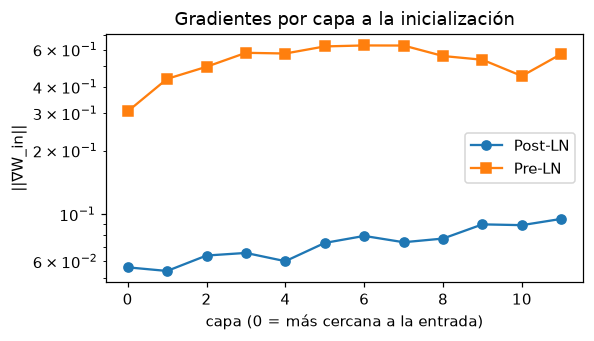

Post-LN  capa 1 / capa 12: 0.59 | Pre-LN capa 1 / capa 12: 0.54


In [ ]:
x = torch.randn(2, 10, 64)
post = nn.TransformerEncoderLayer(d_model=64, nhead=8, dim_feedforward=256, dropout=0.1, batch_first=True, norm_first=False).eval()
pre  = nn.TransformerEncoderLayer(d_model=64, nhead=8, dim_feedforward=256, dropout=0.1, batch_first=True, norm_first=True).eval()
mask = nn.Transformer.generate_square_subsequent_mask(10)
with torch.no_grad():
    print("Post-LN:", tuple(post(x).shape), "| Pre-LN:", tuple(pre(x, src_mask=mask, is_causal=True).shape))

def grad_norm_first_layer(norm_first, depth=12):
    torch.manual_seed(0)
    layers = nn.ModuleList([nn.TransformerEncoderLayer(64, 8, 256, 0.0, batch_first=True, norm_first=norm_first) for _ in range(depth)])
    z = torch.randn(4, 16, 64); target = torch.randn(4, 16, 64)
    for l in layers: z = l(z)
    F.mse_loss(z, target).backward()
    return [next(l.parameters()).grad.norm().item() for l in layers]

g_post, g_pre = grad_norm_first_layer(False), grad_norm_first_layer(True)
plt.figure(figsize=(5.5, 3.2))
plt.plot(g_post, "o-", label="Post-LN"); plt.plot(g_pre, "s-", label="Pre-LN")
plt.xlabel("capa (0 = más cercana a la entrada)"); plt.ylabel("||∇W_in||"); plt.yscale("log"); plt.legend()
plt.title("Gradientes por capa a la inicialización"); plt.tight_layout(); save("B3_postln_vs_preln")
print("Post-LN  capa 1 / capa 12:", round(g_post[0] / g_post[-1], 2), "| Pre-LN capa 1 / capa 12:", round(g_pre[0] / g_pre[-1], 2))

## Parte C — Costo computacional de la self-attention vs longitud `n`

Comparamos una implementación ingenua (materializa la matriz $n\times n$) con `F.scaled_dot_product_attention` (usa kernels fusionados tipo FlashAttention cuando el hardware lo permite).
Se mide tiempo y memoria de la matriz de atención. Se espera pendiente ≈ 2 en escala log-log para el tiempo del método ingenuo.

Pendiente log-log tiempo manual, todos los n: 1.54 (sesgada por overhead en n pequeño)
Pendiente log-log tiempo manual, n ≥ 1024:    2.10  (teórico ≈ 2)
Pendiente log-log tiempo SDPA,   n ≥ 1024:    1.97
Pendiente log-log memoria pico,  n ≥ 1024:    1.90  (teórico = 2)


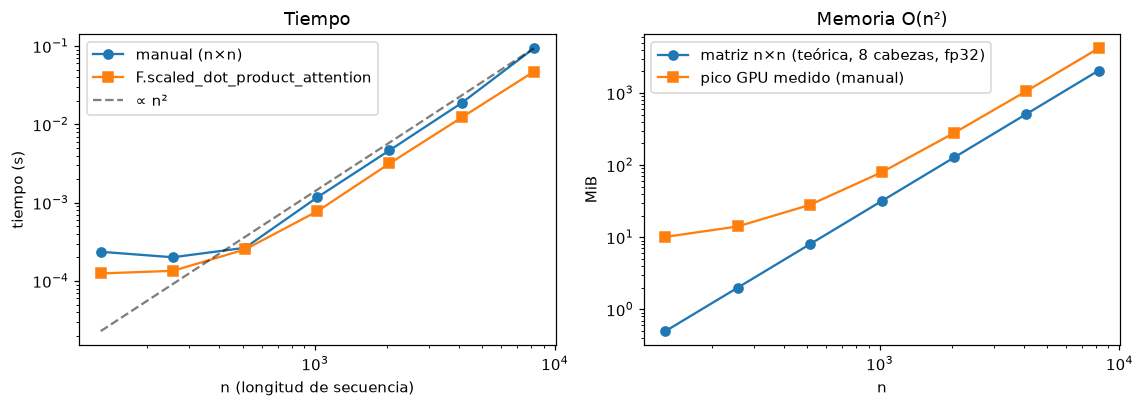

,n,t_manual (s),t_SDPA (s),mem matriz atención (MiB),pico GPU manual (MiB)
0,128,0.0002,0.0001,0.5,10.125
1,256,0.0002,0.0001,2.0,14.125
2,512,0.0003,0.0003,8.0,28.125
3,1024,0.0012,0.0008,32.0,80.125
4,2048,0.0047,0.0032,128.0,280.125
5,4096,0.0188,0.0122,512.0,1064.125
6,8192,0.0937,0.0472,2048.0,4168.125


In [ ]:
def bench(fn, reps=10):
    fn()                                      # calentamiento
    ts = []
    for _ in range(reps):
        if device == "cuda": torch.cuda.synchronize()
        t0 = time.perf_counter(); fn()
        if device == "cuda": torch.cuda.synchronize()
        ts.append(time.perf_counter() - t0)
    return float(np.median(ts))

ns = [128, 256, 512, 1024, 2048] + ([4096, 8192] if device == "cuda" else [])
Hh, Ee = 8, 64
rows = []
with torch.no_grad():
    for n in ns:
        q, k, v = (torch.randn(1, Hh, n, Ee, device=device) for _ in range(3))
        t_man = bench(lambda: manual_attn(q, k, v))
        t_sdp = bench(lambda: F.scaled_dot_product_attention(q, k, v))
        mem_teo = Hh * n * n * 4 / 2**20        # MiB de la matriz de atención en fp32
        mem_peak = np.nan
        if device == "cuda":
            torch.cuda.reset_peak_memory_stats(); manual_attn(q, k, v)
            mem_peak = torch.cuda.max_memory_allocated() / 2**20
        rows.append({"n": n, "t_manual (s)": t_man, "t_SDPA (s)": t_sdp,
                     "mem matriz atención (MiB)": mem_teo, "pico GPU manual (MiB)": mem_peak})
cost = pd.DataFrame(rows)
cost.to_csv("results/costo_atencion.csv", index=False)

# Para n pequeño el tiempo en GPU lo domina el overhead de lanzar kernels, no el cómputo en sí;
# la pendiente se ajusta solo en el régimen grande (n ≥ 1024), donde domina el término n².
big = cost.n >= 1024
slope_all = np.polyfit(np.log(cost.n), np.log(cost["t_manual (s)"]), 1)[0]
slope = np.polyfit(np.log(cost.n[big]), np.log(cost["t_manual (s)"][big]), 1)[0]
slope_sdpa = np.polyfit(np.log(cost.n[big]), np.log(cost["t_SDPA (s)"][big]), 1)[0]
slope_mem = np.polyfit(np.log(cost.n[big]), np.log(cost["pico GPU manual (MiB)"][big]), 1)[0] if device == "cuda" else np.nan
print(f"Pendiente log-log tiempo manual, todos los n: {slope_all:.2f} (sesgada por overhead en n pequeño)")
print(f"Pendiente log-log tiempo manual, n ≥ 1024:    {slope:.2f}  (teórico ≈ 2)")
print(f"Pendiente log-log tiempo SDPA,   n ≥ 1024:    {slope_sdpa:.2f}")
print(f"Pendiente log-log memoria pico,  n ≥ 1024:    {slope_mem:.2f}  (teórico = 2)")

fig, ax = plt.subplots(1, 2, figsize=(10.5, 3.8))
ax[0].loglog(cost.n, cost["t_manual (s)"], "o-", label="manual (n×n)")
ax[0].loglog(cost.n, cost["t_SDPA (s)"], "s-", label="F.scaled_dot_product_attention")
ref = cost["t_manual (s)"].iloc[-1] * (cost.n / cost.n.iloc[-1]) ** 2   # referencia anclada en el n mayor
ax[0].loglog(cost.n, ref, "k--", alpha=.5, label="∝ n²")
ax[0].set_xlabel("n (longitud de secuencia)"); ax[0].set_ylabel("tiempo (s)"); ax[0].set_title("Tiempo"); ax[0].legend()
ax[1].loglog(cost.n, cost["mem matriz atención (MiB)"], "o-", label="matriz n×n (teórica, 8 cabezas, fp32)")
if device == "cuda":
    ax[1].loglog(cost.n, cost["pico GPU manual (MiB)"], "s-", label="pico GPU medido (manual)")
ax[1].set_xlabel("n"); ax[1].set_ylabel("MiB"); ax[1].set_title("Memoria O(n²)"); ax[1].legend()
plt.tight_layout(); save("C_costo_atencion")
cost.round(4)

**Resultado.** Para $n\ge1024$ el tiempo de la implementación ingenua crece con pendiente 2.10 en escala log-log y la memoria pico con 1.90, como predice $O(n^2)$; en $n=8192$ la matriz de atención ocupa 2 GiB (8 cabezas, fp32) y el pico medido es ≈ 4 GiB.
Para $n$ pequeño la curva es casi plana porque domina el costo fijo de lanzar kernels en la GPU (ajustando todos los puntos la pendiente sería solo 1.54).
`F.scaled_dot_product_attention` usa kernels fusionados y es ≈ 2× más rápido en $n=8192$, pero sus FLOPs siguen siendo cuadráticos (pendiente 1.97).

## Parte D — Modelos preentrenados: BERT y GPT-2

Se requiere conexión a internet la primera vez (descarga de Hugging Face; ~0.5 GB por modelo).
`attn_implementation="eager"` es obligatorio para obtener los pesos de atención (las implementaciones `sdpa`/FlashAttention no los devuelven).

In [11]:
from transformers import AutoTokenizer, AutoModel

tok_bert = AutoTokenizer.from_pretrained("bert-base-uncased")
bert = AutoModel.from_pretrained("bert-base-uncased", output_attentions=True, attn_implementation="eager").eval()
tok_gpt2 = AutoTokenizer.from_pretrained("gpt2")
gpt2 = AutoModel.from_pretrained("gpt2", output_attentions=True, attn_implementation="eager").eval()

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

In [12]:
@torch.no_grad()
def get_attn(model, tok, text):
    # Devuelve (tokens, atención) con atención de forma (capas, cabezas, n, n); filas = query, columnas = key
    enc = tok(text, return_tensors="pt")
    out = model(**enc)
    att = torch.stack(out.attentions).squeeze(1)
    toks = [t.replace("Ġ", "") for t in tok.convert_ids_to_tokens(enc["input_ids"][0])]
    return toks, att

SENT = "The cat sat on the mat, and then it jumped onto the table."
toks_b, att_b = get_attn(bert, tok_bert, SENT)
toks_g, att_g = get_attn(gpt2, tok_gpt2, SENT)
print("BERT :", len(toks_b), "tokens |", "attn:", tuple(att_b.shape), "(capas, cabezas, n, n)")
print("GPT-2:", len(toks_g), "tokens |", "attn:", tuple(att_g.shape))
print(toks_b); print(toks_g)
print("Filas suman 1:", torch.allclose(att_b.sum(-1), torch.ones_like(att_b.sum(-1)), atol=1e-4))

BERT : 17 tokens | attn: (12, 12, 17, 17) (capas, cabezas, n, n)
GPT-2: 15 tokens | attn: (12, 12, 15, 15)
['[CLS]', 'the', 'cat', 'sat', 'on', 'the', 'mat', ',', 'and', 'then', 'it', 'jumped', 'onto', 'the', 'table', '.', '[SEP]']
['The', 'cat', 'sat', 'on', 'the', 'mat', ',', 'and', 'then', 'it', 'jumped', 'onto', 'the', 'table', '.']
Filas suman 1: True


### D.1 Perfil de cada cabeza

En lugar de elegir cabezas al azar, medimos para **cada una de las 144 cabezas** cuánta atención media dedican a: el token anterior (`prev`), el siguiente (`next`, solo BERT), ella misma (`self`),
el primer token / `[CLS]` (`first`), `[SEP]` (solo BERT) y la puntuación (`punct`). Luego se grafican las cabezas más representativas de capas distintas.

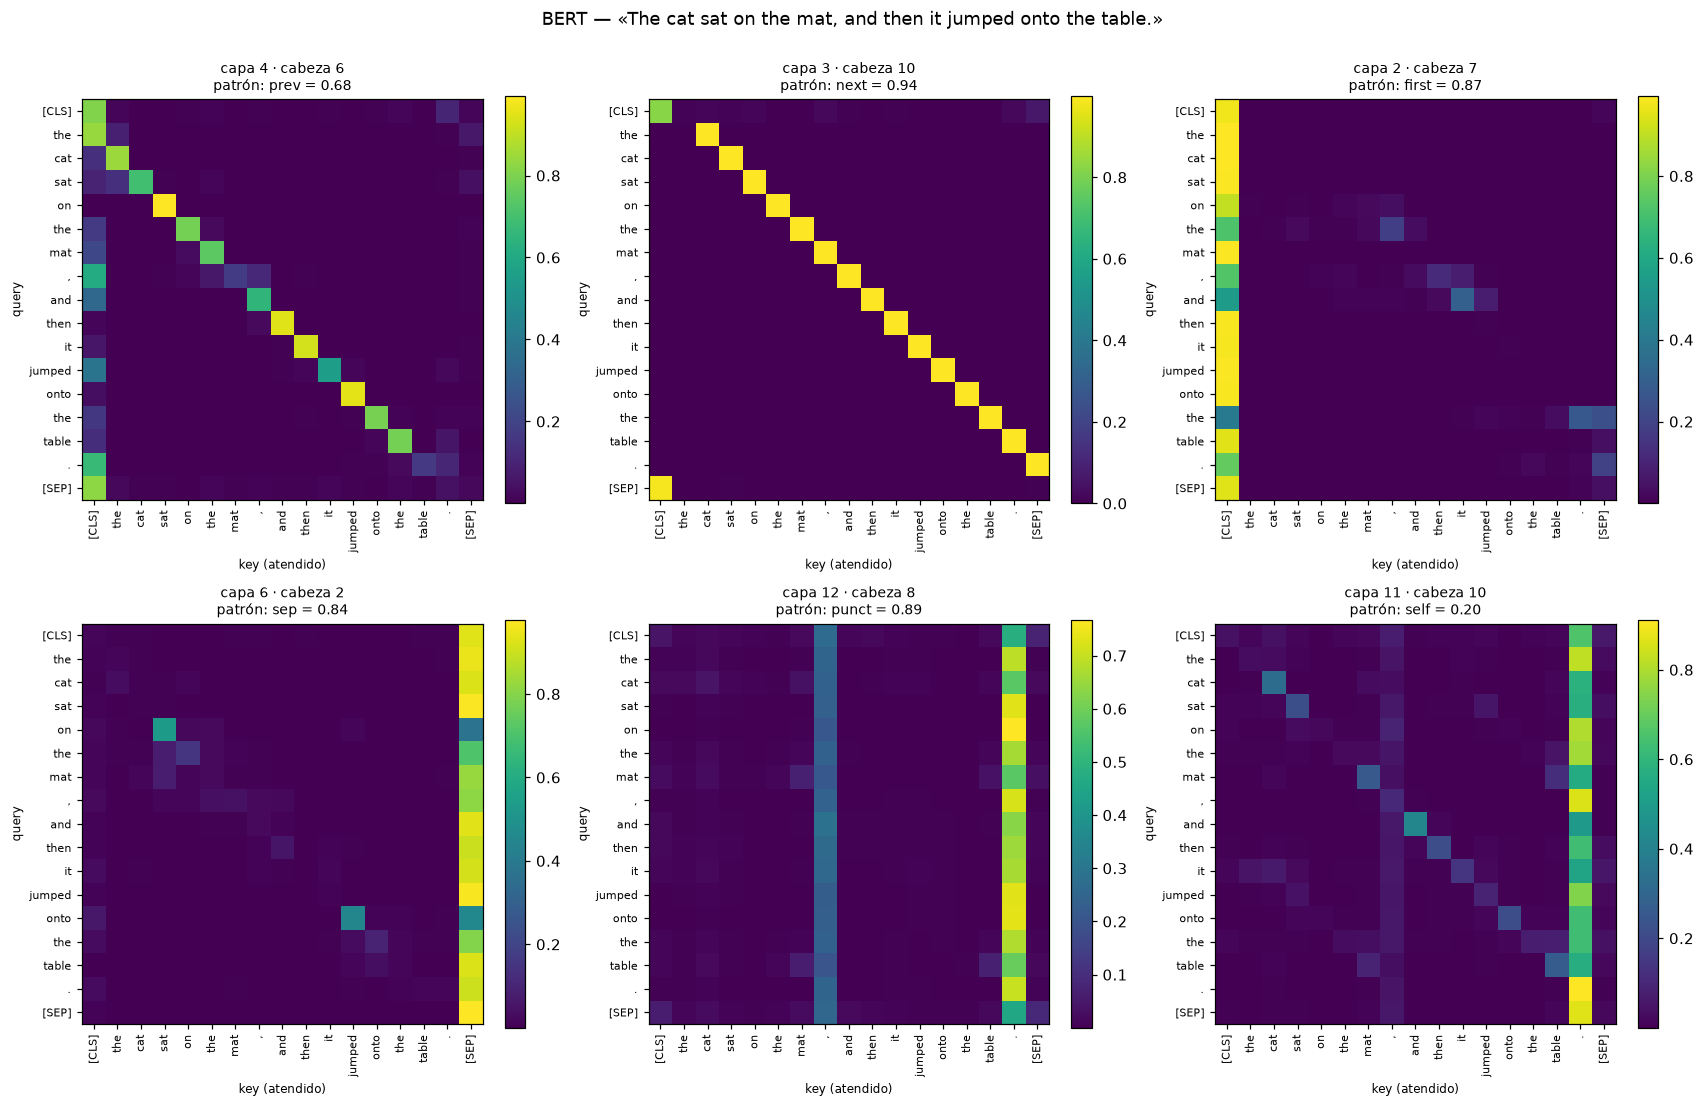

In [13]:
PUNCT = set(".,;:!?'\"-()")

def head_profile(toks, att, kind):
    L, H, n, _ = att.shape
    i = torch.arange(n)
    cols = {
        "prev":  att[:, :, i[1:], i[:-1]].mean(-1),
        "self":  att[:, :, i, i].mean(-1),
        "first": att[:, :, 1:, 0].mean(-1),             # consultas i>=1 hacia el primer token
    }
    if kind == "bert":
        cols["next"] = att[:, :, i[:-1], i[1:]].mean(-1)
        cols["sep"]  = att[:, :, :, n - 1].mean(-1)
    pidx = [j for j, t in enumerate(toks) if t in PUNCT]
    cols["punct"] = att[:, :, :, pidx].sum(-1).mean(-1) if pidx else torch.zeros(L, H)
    df = pd.DataFrame({k: v.flatten().numpy() for k, v in cols.items()})
    df.insert(0, "head", np.tile(np.arange(H), L)); df.insert(0, "layer", np.repeat(np.arange(L), H))
    return df

def pick_distinct_layers(df, metrics):
    chosen, used = [], set()
    for m in metrics:
        for _, r in df.sort_values(m, ascending=False).iterrows():
            if int(r.layer) not in used:
                chosen.append((int(r.layer), int(r["head"]), m, float(r[m]))); used.add(int(r.layer)); break
    return chosen

def plot_heads(toks, att, chosen, title, fname, ncols=3):
    nrows = math.ceil(len(chosen) / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(5.2 * ncols, 5 * nrows))
    axes = np.atleast_1d(axes).ravel()
    for ax, (l, h, m, val) in zip(axes, chosen):
        im = ax.imshow(att[l, h].numpy(), cmap="viridis")
        ax.set_xticks(range(len(toks))); ax.set_xticklabels(toks, rotation=90, fontsize=7)
        ax.set_yticks(range(len(toks))); ax.set_yticklabels(toks, fontsize=7)
        ax.set_title(f"capa {l+1} · cabeza {h+1}\npatrón: {m} = {val:.2f}", fontsize=9)
        ax.set_xlabel("key (atendido)", fontsize=8); ax.set_ylabel("query", fontsize=8)
        plt.colorbar(im, ax=ax, fraction=0.046)
    for ax in axes[len(chosen):]: ax.axis("off")
    fig.suptitle(title, y=1.0); plt.tight_layout(); save(fname)

prof_b = head_profile(toks_b, att_b, "bert");  prof_b.to_csv("results/perfil_cabezas_bert.csv", index=False)
prof_g = head_profile(toks_g, att_g, "gpt2");  prof_g.to_csv("results/perfil_cabezas_gpt2.csv", index=False)

ch_b = pick_distinct_layers(prof_b, ["prev", "next", "first", "sep", "punct", "self"])
plot_heads(toks_b, att_b, ch_b, f"BERT — «{SENT}»", "D1_bert_cabezas")

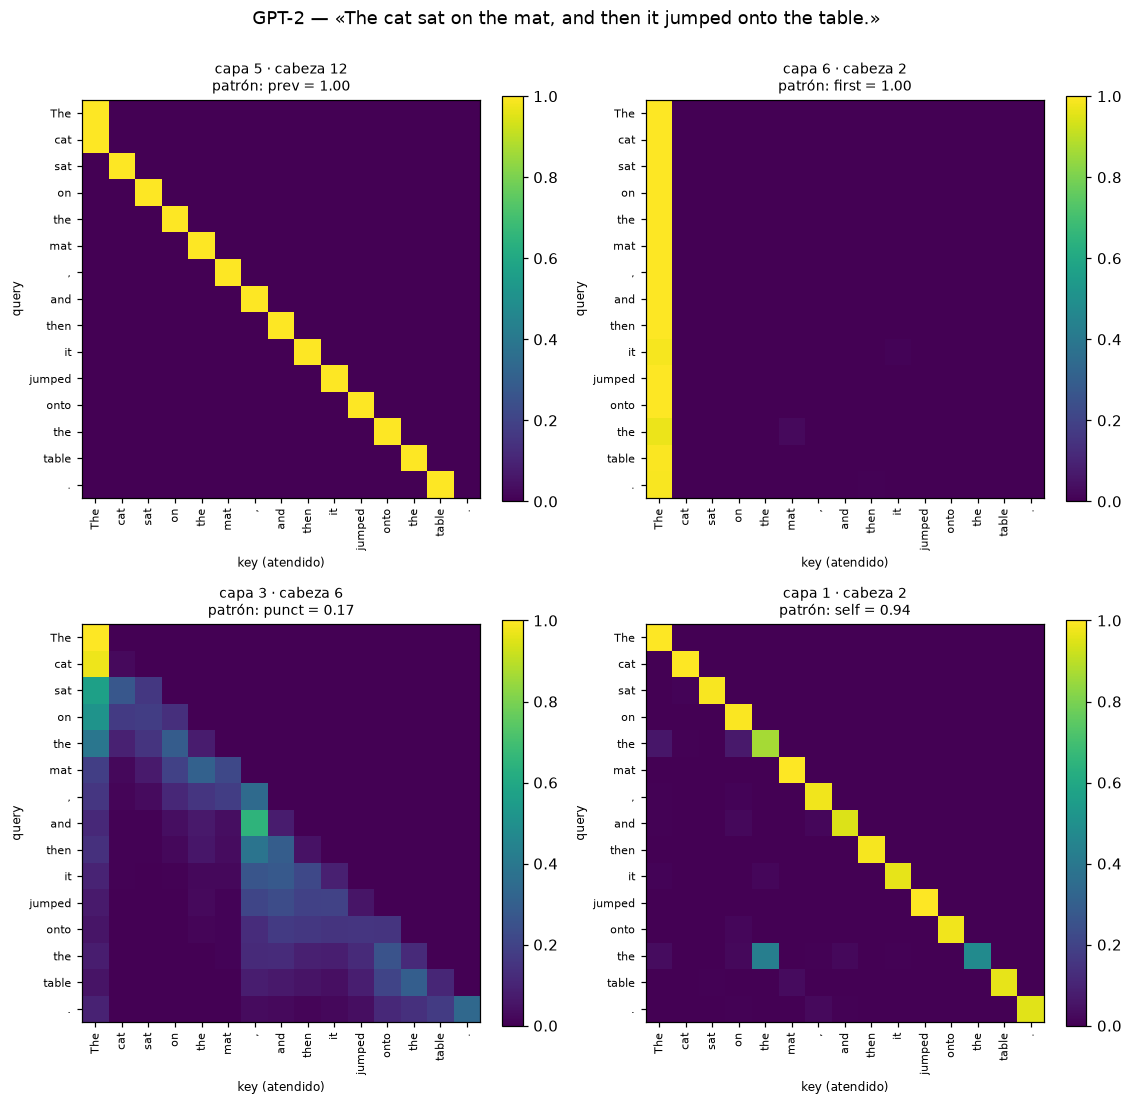

In [14]:
ch_g = pick_distinct_layers(prof_g, ["prev", "first", "punct", "self"])
plot_heads(toks_g, att_g, ch_g, f"GPT-2 — «{SENT}»", "D1_gpt2_cabezas", ncols=2)

**Interpretación.** Cómo leer los mapas: (1) diagonal desplazada = atención al token anterior/siguiente; (2) columna vertical en `[CLS]`/`[SEP]`/primer token = *sink* o «no-op»;
(3) columnas en `,` `.` = atención a puntuación; (4) diagonal principal = atención a sí mismo. En GPT-2 todo lo que está sobre la diagonal es 0 (máscara causal).

- **BERT:** cabezas posicionales muy limpias (capa 3·cabeza 10 atiende al token *siguiente* con 0.94; capa 4·cabeza 6 al *anterior* con 0.68), una cabeza que manda casi todo a `[CLS]` (capa 2·cabeza 7) y muchas a `[SEP]` (capa 6·cabeza 2, 0.84).
  En capas profundas aparece atención masiva a la puntuación (capa 12·cabeza 8: 0.89 de la masa en `,` y `.`). Ninguna cabeza de BERT atiende principalmente a sí misma (la mejor, capa 11·cabeza 10, solo llega a 0.20 y en realidad es una cabeza de «.»).
- **GPT-2:** una cabeza de *token anterior* perfecta (capa 5·cabeza 12, 1.00), cabezas de *sí mismo* en la capa 1 (capa 1·cabeza 2, 0.94) y cabezas que depositan toda la masa en el primer token (capa 6·cabeza 2, 1.00). GPT-2 no tiene cabezas de puntuación.

In [15]:
# Cuántas cabezas "especializadas" hay por patrón (umbral 0.5 de atención media)
resumen = pd.DataFrame({
    "BERT": {m: int((prof_b[m] > .5).sum()) for m in ["prev", "next", "self", "first", "sep", "punct"]},
    "GPT-2": {m: int((prof_g[m] > .5).sum()) for m in ["prev", "self", "first", "punct"]},
})
print("Número de cabezas (de 144) con atención media > 0.5 sobre el patrón (esta oración):")
resumen

Número de cabezas (de 144) con atención media > 0.5 sobre el patrón (esta oración):


,BERT,GPT-2
prev,3,2.0
next,5,NaN
self,0,6.0
first,4,99.0
sep,43,NaN
punct,18,0.0


## Parte E — «it» → *animal* o *street* (BERT)


In [16]:
sA = "The animal didn't cross the street because it was too tired."
sB = "The animal didn't cross the street because it was too wide."
tA, aA = get_attn(bert, tok_bert, sA)
tB, aB = get_attn(bert, tok_bert, sB)
print(tA); print(tB)

it, an, st = tA.index("it"), tA.index("animal"), tA.index("street")
assert (tB.index("it"), tB.index("animal"), tB.index("street")) == (it, an, st)

sA_ = aA[:, :, it, an] - aA[:, :, it, st]      # (capas, cabezas); >0 favorece 'animal'
sB_ = aB[:, :, it, an] - aB[:, :, it, st]
delta = sA_ - sB_

rows = []
for l in range(12):
    for h in range(12):
        rows.append({"capa": l + 1, "cabeza": h + 1,
                     "A: it→animal": aA[l, h, it, an].item(), "A: it→street": aA[l, h, it, st].item(),
                     "B: it→animal": aB[l, h, it, an].item(), "B: it→street": aB[l, h, it, st].item(),
                     "Δ = s_A − s_B": delta[l, h].item()})
tab = pd.DataFrame(rows).sort_values("Δ = s_A − s_B", ascending=False)
tab.to_csv("results/pronombre_it_bert.csv", index=False)
tab.head(10).round(3)

['[CLS]', 'the', 'animal', 'didn', "'", 't', 'cross', 'the', 'street', 'because', 'it', 'was', 'too', 'tired', '.', '[SEP]']
['[CLS]', 'the', 'animal', 'didn', "'", 't', 'cross', 'the', 'street', 'because', 'it', 'was', 'too', 'wide', '.', '[SEP]']


,capa,cabeza,A: it→animal,A: it→street,B: it→animal,B: it→street,Δ = s_A − s_B
82,7,11,0.284,0.067,0.012,0.590,0.795
106,9,11,0.676,0.000,0.309,0.259,0.625
116,10,9,0.454,0.003,0.023,0.045,0.474
108,10,1,0.608,0.002,0.255,0.074,0.425
128,11,9,0.564,0.001,0.245,0.078,0.396
100,9,5,0.242,0.014,0.046,0.209,0.390
58,5,11,0.333,0.095,0.167,0.288,0.359
126,11,7,0.714,0.008,0.490,0.108,0.324
109,10,2,0.432,0.016,0.341,0.216,0.291
103,9,8,0.205,0.050,0.061,0.194,0.288


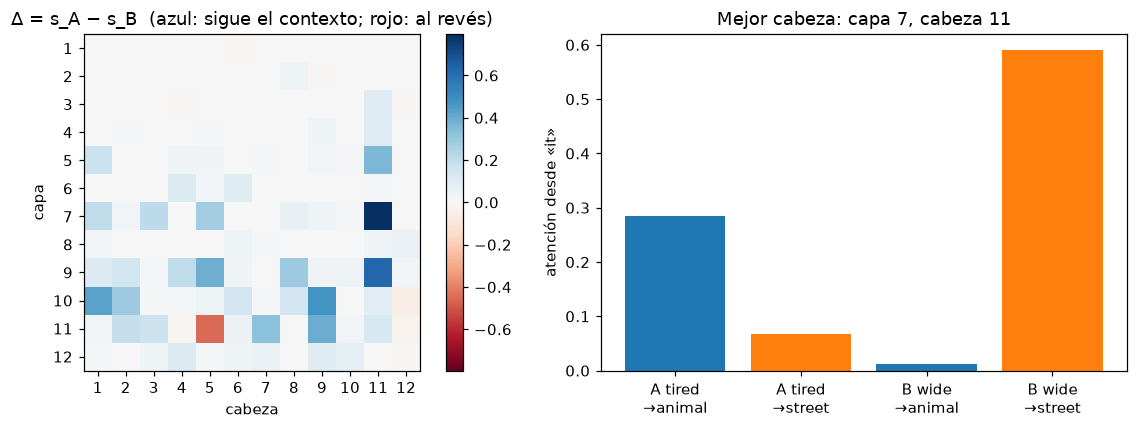

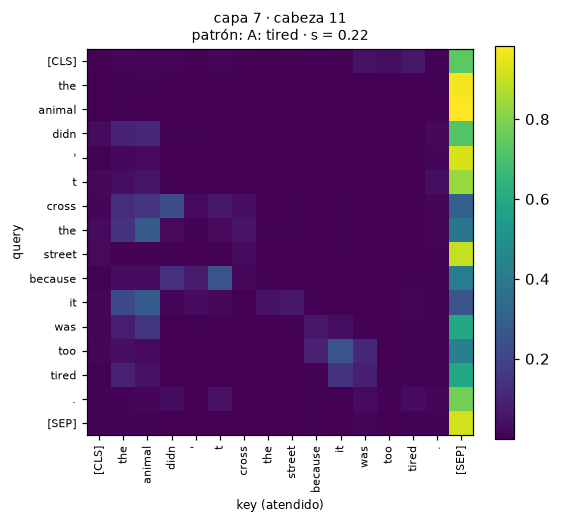

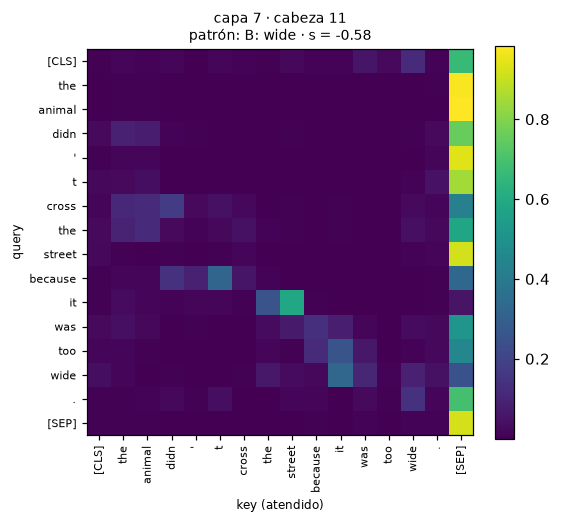

In [17]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
im = ax[0].imshow(delta.numpy(), cmap="RdBu", vmin=-delta.abs().max(), vmax=delta.abs().max())
ax[0].set_xticks(range(12)); ax[0].set_xticklabels(range(1, 13)); ax[0].set_yticks(range(12)); ax[0].set_yticklabels(range(1, 13))
ax[0].set_xlabel("cabeza"); ax[0].set_ylabel("capa"); ax[0].set_title("Δ = s_A − s_B  (azul: sigue el contexto; rojo: al revés)")
plt.colorbar(im, ax=ax[0])

# Barras para la mejor cabeza
l, h = np.unravel_index(delta.argmax().item(), delta.shape)
vals = [aA[l, h, it, an].item(), aA[l, h, it, st].item(), aB[l, h, it, an].item(), aB[l, h, it, st].item()]
ax[1].bar(["A tired\n→animal", "A tired\n→street", "B wide\n→animal", "B wide\n→street"], vals,
          color=["tab:blue", "tab:orange", "tab:blue", "tab:orange"])
ax[1].set_title(f"Mejor cabeza: capa {l+1}, cabeza {h+1}"); ax[1].set_ylabel("atención desde «it»")
plt.tight_layout(); save("E_pronombre_it")

# Mapas completos de esa cabeza en ambas oraciones
plot_heads(tA, aA, [(int(l), int(h), "A: tired · s", sA_[l, h].item())], "", "E_cabeza_A", ncols=1)
plot_heads(tB, aB, [(int(l), int(h), "B: wide · s", sB_[l, h].item())], "", "E_cabeza_B", ncols=1)

In [ ]:
# Cada par: (oración, sustantivo esperado, sustantivo alternativo) para las dos variantes.
PARES = [
    ("The animal didn't cross the street because it was too tired.", "animal", "street"),
    ("The animal didn't cross the street because it was too wide.", "street", "animal"),
    ("The trophy didn't fit in the suitcase because it was too big.", "trophy", "suitcase"),
    ("The trophy didn't fit in the suitcase because it was too small.", "suitcase", "trophy"),
    ("The horse didn't jump the fence because it was too tired.", "horse", "fence"),
    ("The horse didn't jump the fence because it was too high.", "fence", "horse"),
    ("The car couldn't climb the hill because it was too weak.", "car", "hill"),
    ("The car couldn't climb the hill because it was too steep.", "hill", "car"),
    ("The bird didn't eat the seed because it was too full.", "bird", "seed"),
    ("The bird didn't eat the seed because it was too hard.", "seed", "bird"),
    ("The dog didn't cross the river because it was too scared.", "dog", "river"),
    ("The dog didn't cross the river because it was too deep.", "river", "dog"),
]

aciertos = torch.zeros(12, 12)
for s, ok, alt in PARES:
    t, a = get_attn(bert, tok_bert, s)
    i_it, i_ok, i_alt = t.index("it"), t.index(ok), t.index(alt)
    aciertos += (a[:, :, i_it, i_ok] > a[:, :, i_it, i_alt]).float()
acc = aciertos / len(PARES)                      # (capas, cabezas): fracción de oraciones resueltas «correctamente»

top = [(int(l), int(h)) for l, h in zip(*np.unravel_index(np.argsort(-delta.flatten().numpy())[:5], delta.shape))]
rob = pd.DataFrame([{"capa": l + 1, "cabeza": h + 1, "Δ (par original)": round(delta[l, h].item(), 3),
                     f"aciertos ({len(PARES)} oraciones)": f"{int(aciertos[l, h])}/{len(PARES)}"} for l, h in top])
print("Mejores cabezas del par original, evaluadas en", len(PARES), "oraciones (6 pares):")
display(rob)
lb, hb = np.unravel_index(acc.argmax().item(), acc.shape)
print(f"Cabeza con más aciertos en todo el conjunto: capa {lb+1}, cabeza {hb+1} -> {int(aciertos[lb, hb])}/{len(PARES)}")
print(f"Azar = 50 %. Cabezas con ≥ 10/12 aciertos: {int((aciertos >= 10).sum())} de 144")


Mejores cabezas del par original, evaluadas en 12 oraciones (6 pares):


,capa,cabeza,Δ (par original),aciertos (12 oraciones)
0,7,11,0.795,10/12
1,9,11,0.625,7/12
2,10,9,0.474,10/12
3,10,1,0.425,6/12
4,11,9,0.396,8/12


Cabeza con más aciertos en todo el conjunto: capa 7, cabeza 11 -> 10/12
Azar = 50 %. Cabezas con ≥ 10/12 aciertos: 8 de 144


**Resultado.** La capa 7·cabeza 11 es la más sensible al contexto: con *tired* «it» atiende más a *animal* (0.28 vs 0.07) y con *wide* a *street* (0.59 vs 0.01), Δ = 0.80.
Como con 144 cabezas y un solo par algún Δ grande podría ser azar, se evaluó en 6 pares (12 oraciones) tipo Winograd: la misma cabeza elige el sustantivo correcto en 10/12 oraciones (azar = 6/12),
mientras que otras cabezas con Δ alto en el par original (p. ej. capa 9·cabeza 11, 7/12) no generalizan. Solo 8 de 144 cabezas llegan a ≥ 10/12.
Es evidencia de una cabeza con comportamiento de correferencia en capas intermedias, como reporta Clark et al. (2019), aunque no prueba que el modelo *use* esa cabeza para decidir.

## Parte F — GPT-2: máscara causal y *attention sinks*

1. Verificar que la parte estrictamente superior de cada matriz es 0.
2. Medir la proporción de atención que recibe el primer token en cada capa (consultas $i\ge1$; la consulta 0 solo puede atenderse a sí misma).
3. Compararla con el valor de referencia de atención uniforme sobre las llaves visibles ($1/(i+1)$).

n = 45
máx. valor en el triángulo superior: 0.0
¿matriz triangular inferior en todas las capas/cabezas? True


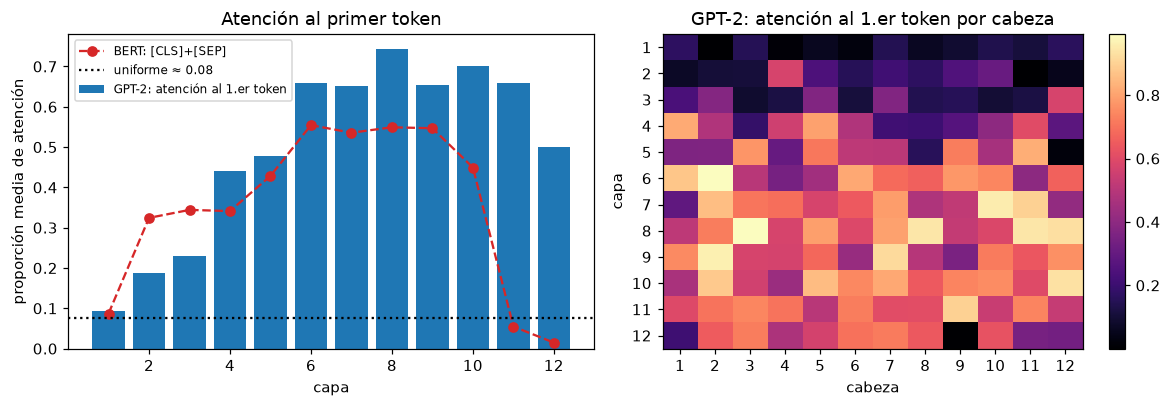

,capa,GPT-2 → 1.er token,BERT → [CLS]+[SEP]
0,1,0.094,0.087
1,2,0.187,0.324
2,3,0.230,0.344
3,4,0.440,0.341
4,5,0.477,0.429
5,6,0.658,0.554
6,7,0.652,0.536
7,8,0.743,0.549
8,9,0.654,0.547
9,10,0.701,0.449


In [19]:
TEXT = ("Attention sinks are tokens that receive a surprisingly large share of the attention mass, "
        "even when they carry little semantic content. Language models trained with softmax attention "
        "tend to dump unneeded attention on the first positions of the sequence.")
tg, ag = get_attn(gpt2, tok_gpt2, TEXT)
n = len(tg); print("n =", n)

# 1) triangular inferior
upper = torch.triu(torch.ones(n, n, dtype=torch.bool), diagonal=1)
print("máx. valor en el triángulo superior:", ag[:, :, upper].max().item())
print("¿matriz triangular inferior en todas las capas/cabezas?", bool(ag[:, :, upper].max() < 1e-6))

# 2) proporción en el primer token por capa
first_share = ag[:, :, 1:, 0].mean(dim=(1, 2)).numpy()                  # (capas,)
uniform = float(np.mean([1 / (i + 1) for i in range(1, n)]))
share_head = ag[:, :, 1:, 0].mean(-1).numpy()                           # (capas, cabezas)

# Contraste con BERT: atención a [CLS] + [SEP] por capa
tb, ab = get_attn(bert, tok_bert, TEXT)
bert_special = (ab[:, :, :, 0] + ab[:, :, :, -1]).mean(dim=(1, 2)).numpy()

fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
ax[0].bar(range(1, 13), first_share, label="GPT-2: atención al 1.er token")
ax[0].plot(range(1, 13), bert_special, "o--", color="tab:red", label="BERT: [CLS]+[SEP]")
ax[0].axhline(uniform, color="k", ls=":", label=f"uniforme ≈ {uniform:.2f}")
ax[0].set_xlabel("capa"); ax[0].set_ylabel("proporción media de atención"); ax[0].legend(fontsize=8); ax[0].set_title("Atención al primer token")
im = ax[1].imshow(share_head, cmap="magma", aspect="auto"); plt.colorbar(im, ax=ax[1])
ax[1].set_xticks(range(12)); ax[1].set_xticklabels(range(1, 13)); ax[1].set_yticks(range(12)); ax[1].set_yticklabels(range(1, 13))
ax[1].set_xlabel("cabeza"); ax[1].set_ylabel("capa"); ax[1].set_title("GPT-2: atención al 1.er token por cabeza")
plt.tight_layout(); save("F_attention_sink")

pd.DataFrame({"capa": range(1, 13), "GPT-2 → 1.er token": first_share.round(3), "BERT → [CLS]+[SEP]": bert_special.round(3)})

In [ ]:
# ¿El efecto depende del contenido del primer token? Cambiar primera palabra y repetir
variantes = {"original": TEXT, "primer token = 'Banana'": "Banana " + TEXT, "primer token = '.'": ". " + TEXT}
fila = {}
for nombre, txt in variantes.items():
    _, a = get_attn(gpt2, tok_gpt2, txt)
    fila[nombre] = a[:, :, 1:, 0].mean(dim=(1, 2)).numpy().round(3)
pd.DataFrame(fila, index=range(1, 13)).rename_axis("capa")

,original,primer token = 'Banana',primer token = '.'
capa,,,
1,0.094,0.081,0.094
2,0.187,0.184,0.205
3,0.230,0.231,0.223
4,0.440,0.441,0.443
5,0.477,0.472,0.478
6,0.658,0.656,0.658
7,0.652,0.645,0.651
8,0.743,0.738,0.736
9,0.654,0.649,0.653


**Resultado e interpretación.** La parte estrictamente superior es exactamente 0 en las 144 cabezas (máscara causal). La proporción de atención al primer token crece de 0.09 (capa 1, ≈ la línea base uniforme de 0.08) a 0.74 en la capa 8 y se mantiene ≥ 0.5 hasta la capa 12;
hay cabezas que depositan > 95 % de la masa ahí. Cambiar la primera palabra por *Banana* o «.» casi no altera estos valores (diferencias ≤ 0.02): el efecto depende de la posición, no de la semántica.
Esto coincide con Xiao et al. (2023, arXiv:2309.17453): como la softmax obliga a que cada fila sume 1, el modelo necesita un «sumidero» donde depositar la atención sobrante cuando ninguna llave es relevante,
y el primer token (visible para todas las consultas) cumple ese papel. Por eso *StreamingLLM* conserva los primeros tokens en la caché KV junto a una ventana deslizante.
En BERT el papel de sumidero lo cumplen `[CLS]`/`[SEP]` en las capas intermedias (≈ 0.55), pero desaparece en las capas 11–12 (≤ 0.06), donde la masa pasa a la puntuación.

## Parte G — Entropía de la atención por capa



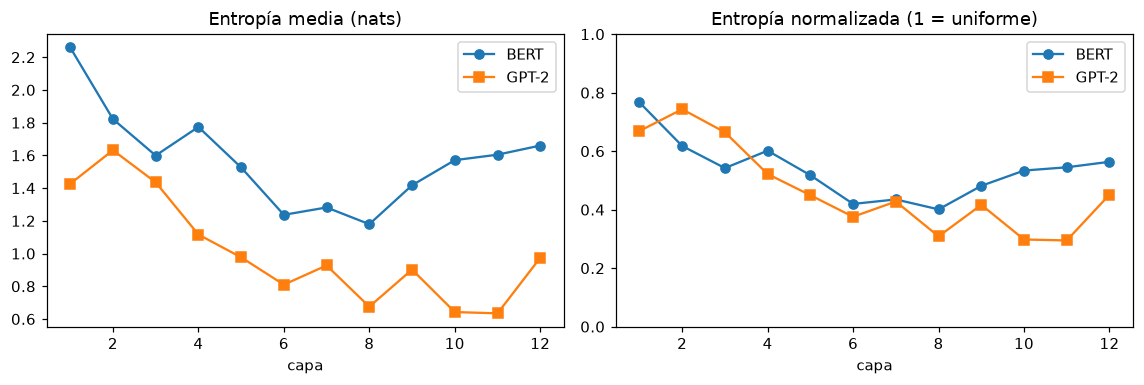

,capa,BERT (nats),GPT-2 (nats),BERT (norm.),GPT-2 (norm.)
0,1,2.259,1.426,0.767,0.669
1,2,1.822,1.631,0.618,0.743
2,3,1.599,1.435,0.542,0.665
3,4,1.774,1.116,0.602,0.522
4,5,1.526,0.977,0.518,0.449
5,6,1.237,0.810,0.420,0.376
6,7,1.282,0.927,0.435,0.428
7,8,1.179,0.675,0.401,0.309
8,9,1.417,0.902,0.481,0.416
9,10,1.571,0.642,0.534,0.298


In [21]:
CORPUS = [
    "The animal didn't cross the street because it was too tired.",
    "Scientists announced a new method for training large neural networks with far less energy.",
    "She opened the window, looked at the quiet street, and decided to walk to the old library.",
    "Although the experiment failed twice, the team kept improving the design until it finally worked.",
    "In 2017, a paper titled Attention Is All You Need introduced the Transformer architecture.",
    "The river runs through the valley, and the farmers who live nearby depend on it for water.",
    "If the model attends to the wrong token, the prediction can change in surprising ways.",
    "Guatemala is a country in Central America with volcanoes, lakes, and a rich cultural history.",
]

def entropy_rows(att, causal):
    # att (L,H,n,n) -> (entropía cruda, normalizada) de forma (L,H,n)
    n = att.size(-1)
    Hraw = -(att * att.clamp_min(1e-12).log()).sum(-1)
    visibles = torch.arange(1, n + 1).float() if causal else torch.full((n,), float(n))
    return Hraw, Hraw / visibles.log().clamp_min(1e-12), visibles

def mean_entropy_by_layer(model, tok, causal):
    raw, norm = [], []
    for s in CORPUS:
        _, a = get_attn(model, tok, s)
        Hr, Hn, vis = entropy_rows(a, causal)
        sl = slice(1, None) if causal else slice(0, None)   # GPT-2: se omite la fila 0 (trivial, H=0)
        raw.append(Hr[:, :, sl].mean(dim=(1, 2))); norm.append(Hn[:, :, sl].mean(dim=(1, 2)))
    return torch.stack(raw).mean(0).numpy(), torch.stack(norm).mean(0).numpy()

eb_raw, eb_norm = mean_entropy_by_layer(bert, tok_bert, causal=False)
eg_raw, eg_norm = mean_entropy_by_layer(gpt2, tok_gpt2, causal=True)

fig, ax = plt.subplots(1, 2, figsize=(10.5, 3.6))
x = range(1, 13)
ax[0].plot(x, eb_raw, "o-", label="BERT"); ax[0].plot(x, eg_raw, "s-", label="GPT-2")
ax[0].set_title("Entropía media (nats)"); ax[0].set_xlabel("capa"); ax[0].legend()
ax[1].plot(x, eb_norm, "o-", label="BERT"); ax[1].plot(x, eg_norm, "s-", label="GPT-2")
ax[1].set_title("Entropía normalizada (1 = uniforme)"); ax[1].set_xlabel("capa"); ax[1].set_ylim(0, 1); ax[1].legend()
plt.tight_layout(); save("G_entropia_por_capa")

ent = pd.DataFrame({"capa": x, "BERT (nats)": eb_raw, "GPT-2 (nats)": eg_raw, "BERT (norm.)": eb_norm, "GPT-2 (norm.)": eg_norm}).round(3)
ent.to_csv("results/entropia_por_capa.csv", index=False)
ent

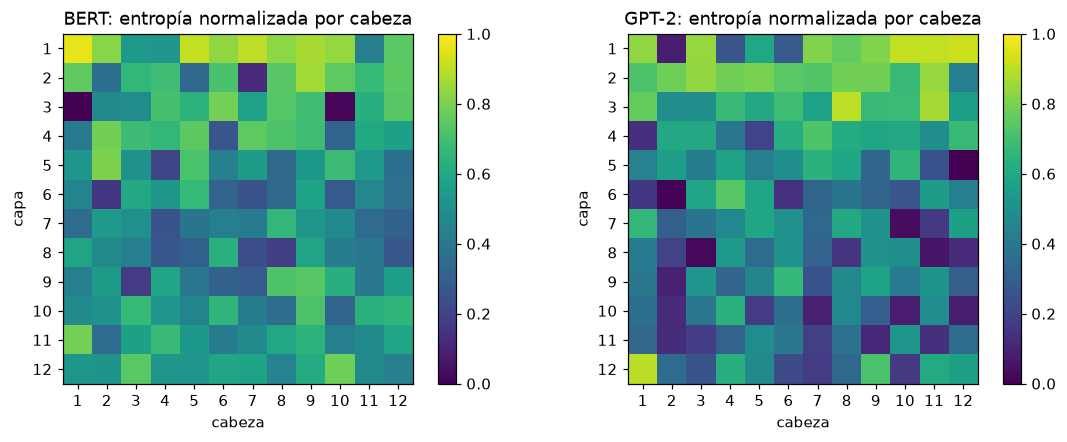

In [22]:
# Entropía por cabeza (normalizada) para ver cabezas "focalizadas" vs "difusas"
def head_entropy_map(model, tok, causal):
    acc = []
    for s in CORPUS:
        _, a = get_attn(model, tok, s)
        _, Hn, _ = entropy_rows(a, causal)
        acc.append(Hn[:, :, 1:].mean(-1) if causal else Hn.mean(-1))
    return torch.stack(acc).mean(0).numpy()

fig, ax = plt.subplots(1, 2, figsize=(10.5, 4))
for a, (name, m, t, c) in zip(ax, [("BERT", bert, tok_bert, False), ("GPT-2", gpt2, tok_gpt2, True)]):
    im = a.imshow(head_entropy_map(m, t, c), cmap="viridis", vmin=0, vmax=1)
    a.set_title(f"{name}: entropía normalizada por cabeza"); a.set_xlabel("cabeza"); a.set_ylabel("capa")
    a.set_xticks(range(12)); a.set_xticklabels(range(1, 13)); a.set_yticks(range(12)); a.set_yticklabels(range(1, 13))
    plt.colorbar(im, ax=a)
plt.tight_layout(); save("G_entropia_por_cabeza")

**Resultado.** En ambos modelos la entropía normalizada baja con la profundidad: BERT pasa de 0.77 (capa 1) a un mínimo de 0.40 (capa 8) y vuelve a subir a ≈ 0.56 en las últimas capas;
GPT-2 baja de 0.67–0.74 (capas 1–2) a ≈ 0.30 (capas 10–11) y sube a 0.45 en la capa 12. Las capas iniciales atienden de forma difusa (mezcla local amplia) y las profundas de forma más concentrada.
GPT-2 es más concentrado que BERT desde la capa 4, pero buena parte de esa concentración se debe al *attention sink* (masa en el primer token), no a atención «informativa».
El mapa por cabeza muestra además que dentro de una misma capa conviven cabezas casi uniformes y cabezas casi deterministas (entropía ≈ 0).

## Parte H (opcional) — `bertviz`

`pip install bertviz` (ya incluido en `requirements.txt`). Cambien `USE_BERTVIZ = True` para generar las vistas interactivas; solo funcionan dentro de Jupyter.

In [23]:
USE_BERTVIZ = False
if USE_BERTVIZ:
    from bertviz import head_view, model_view
    enc = tok_bert(sA, return_tensors="pt")
    with torch.no_grad():
        out = bert(**enc)
    toks_v = tok_bert.convert_ids_to_tokens(enc["input_ids"][0])
    head_view(out.attentions, toks_v)
    # model_view(out.attentions, toks_v)

## Resumen de resultados

- **Escalamiento (A):** $\mathrm{Var}(q\cdot k)\approx d_k$; sin $1/\sqrt{d_k}$ la softmax se satura ($p_{max}=0.96$ con $d_k=1024$) y el jacobiano cae 6×. Parámetros de multi-head idénticos para $h=1\ldots16$ (1,050,624). Self-attention equivariante a permutaciones (error ≈ 1e-7).
- **PyTorch (B):** SDPA coincide con la implementación manual (con y sin máscara causal); las convenciones de máscara booleana son opuestas entre SDPA y `nn.MultiheadAttention`. Pre-LN da gradientes ~5–8× mayores que Post-LN a la inicialización.
- **Costo (C):** pendiente log-log del tiempo = 2.10 y de la memoria pico = 1.90 para $n\ge1024$ (teórico 2). SDPA (kernels fusionados) es ≈ 2× más rápido en $n=8192$.
- **Patrones por cabeza (D):** BERT: 5 cabezas *next*, 3 *prev*, 43 hacia `[SEP]`, 18 hacia puntuación (umbral 0.5). GPT-2: 99 cabezas con > 0.5 en el primer token, cabezas *prev* y *self* casi perfectas.
- **Pronombre «it» (E):** capa 7·cabeza 11, Δ = 0.80; generaliza a 10/12 oraciones.
- **GPT-2 (F):** matriz triangular inferior verificada; atención al primer token de 0.09 (capa 1) a 0.74 (capa 8), independiente de qué palabra sea → *attention sink*.
- **Entropía (G):** disminuye con la profundidad en ambos modelos (mínimo en capa 8 para BERT, capas 10–11 para GPT-2), con un repunte en las últimas capas.

## Figuras compactas para el informe (PDF)

Las figuras anteriores son anchas para verlas en el notebook; aquí se reagrupan los mismos resultados (variables ya calculadas) en 4 figuras con letra legible a ancho de página.

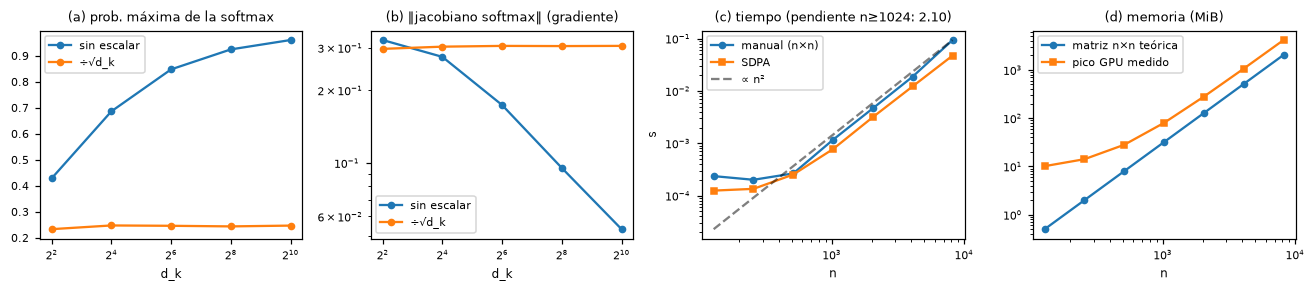

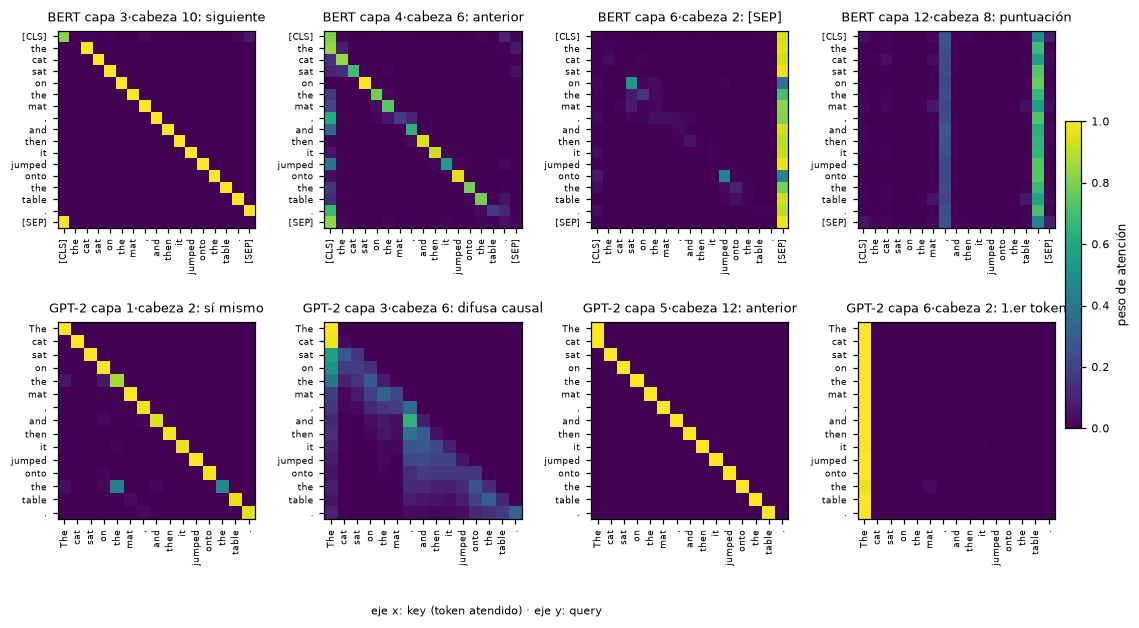

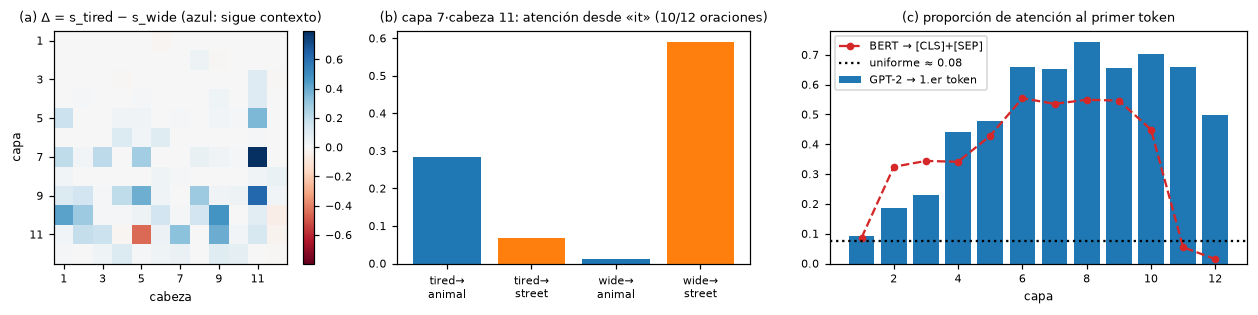

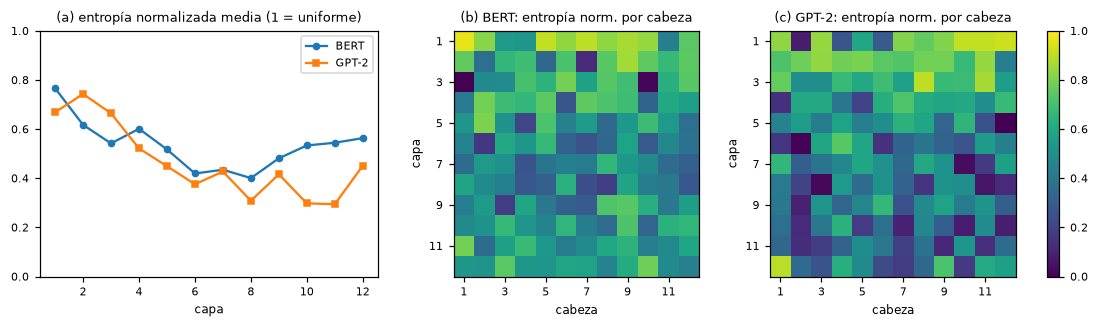

In [ ]:
plt.rcParams.update({"font.size": 8, "axes.titlesize": 8.5, "axes.labelsize": 8, "legend.fontsize": 7,
                     "xtick.labelsize": 7, "ytick.labelsize": 7})

fig, ax = plt.subplots(1, 4, figsize=(12, 2.7))
for sc, lab in ((False, "sin escalar"), (True, "÷√d_k")):
    s = sm[sm.escalado == sc]
    ax[0].plot(s.d_k, s["p_max media"], "o-", ms=4, label=lab)
    ax[1].plot(s.d_k, s["||J_softmax||_F"], "o-", ms=4, label=lab)
ax[0].set_title("(a) prob. máxima de la softmax"); ax[1].set_title("(b) ‖jacobiano softmax‖ (gradiente)")
for a in ax[:2]:
    a.set_xscale("log", base=2); a.set_xlabel("d_k"); a.legend()
ax[1].set_yscale("log")
ax[2].loglog(cost.n, cost["t_manual (s)"], "o-", ms=4, label="manual (n×n)")
ax[2].loglog(cost.n, cost["t_SDPA (s)"], "s-", ms=4, label="SDPA")
ax[2].loglog(cost.n, cost["t_manual (s)"].iloc[-1] * (cost.n / cost.n.iloc[-1]) ** 2, "k--", alpha=.5, label="∝ n²")
ax[2].set_title(f"(c) tiempo (pendiente n≥1024: {slope:.2f})"); ax[2].set_xlabel("n"); ax[2].set_ylabel("s"); ax[2].legend()
ax[3].loglog(cost.n, cost["mem matriz atención (MiB)"], "o-", ms=4, label="matriz n×n teórica")
if device == "cuda":
    ax[3].loglog(cost.n, cost["pico GPU manual (MiB)"], "s-", ms=4, label="pico GPU medido")
ax[3].set_title("(d) memoria (MiB)"); ax[3].set_xlabel("n"); ax[3].legend()
plt.tight_layout(); save("R1_escalamiento_costo")

sel_b = [(2, 9, "siguiente"), (3, 5, "anterior"), (5, 1, "[SEP]"), (11, 7, "puntuación")]   # índices base 0
sel_g = [(0, 1, "sí mismo"), (2, 5, "difusa causal"), (4, 11, "anterior"), (5, 1, "1.er token")]
fig, axes = plt.subplots(2, 4, figsize=(12, 6.3), gridspec_kw={"wspace": 0.35})
for row, (toks, att, sel, name) in enumerate([(toks_b, att_b, sel_b, "BERT"), (toks_g, att_g, sel_g, "GPT-2")]):
    for ax_, (l, h, lab) in zip(axes[row], sel):
        ax_.imshow(att[l, h].numpy(), cmap="viridis", vmin=0, vmax=1)
        ax_.set_xticks(range(len(toks))); ax_.set_xticklabels(toks, rotation=90, fontsize=6)
        ax_.set_yticks(range(len(toks))); ax_.set_yticklabels(toks, fontsize=6)
        ax_.set_title(f"{name} capa {l+1}·cabeza {h+1}: {lab}")
fig.colorbar(plt.cm.ScalarMappable(cmap="viridis"), ax=axes, fraction=0.015, pad=0.01, label="peso de atención")
fig.text(0.45, 0.005, "eje x: key (token atendido) · eje y: query", ha="center", fontsize=7)
save("R2_mapas_atencion")

lb_, hb_ = np.unravel_index(delta.argmax().item(), delta.shape)
fig, ax = plt.subplots(1, 3, figsize=(12, 2.9), gridspec_kw={"width_ratios": [1, 1.1, 1.3]})
m = delta.abs().max().item()
im = ax[0].imshow(delta.numpy(), cmap="RdBu", vmin=-m, vmax=m)
ax[0].set_xticks(range(0, 12, 2)); ax[0].set_xticklabels(range(1, 13, 2)); ax[0].set_yticks(range(0, 12, 2)); ax[0].set_yticklabels(range(1, 13, 2))
ax[0].set_xlabel("cabeza"); ax[0].set_ylabel("capa"); ax[0].set_title("(a) Δ = s_tired − s_wide (azul: sigue contexto)")
plt.colorbar(im, ax=ax[0], fraction=0.046)
vals = [aA[lb_, hb_, it, an].item(), aA[lb_, hb_, it, st].item(), aB[lb_, hb_, it, an].item(), aB[lb_, hb_, it, st].item()]
ax[1].bar(["tired→\nanimal", "tired→\nstreet", "wide→\nanimal", "wide→\nstreet"], vals, color=["tab:blue", "tab:orange"] * 2)
ax[1].set_title(f"(b) capa {lb_+1}·cabeza {hb_+1}: atención desde «it» ({int(aciertos[lb_, hb_])}/{len(PARES)} oraciones)")
ax[2].bar(range(1, 13), first_share, label="GPT-2 → 1.er token")
ax[2].plot(range(1, 13), bert_special, "o--", ms=4, color="tab:red", label="BERT → [CLS]+[SEP]")
ax[2].axhline(uniform, color="k", ls=":", label=f"uniforme ≈ {uniform:.2f}")
ax[2].set_xlabel("capa"); ax[2].set_title("(c) proporción de atención al primer token"); ax[2].legend()
plt.tight_layout(); save("R3_it_y_sink")

fig, ax = plt.subplots(1, 3, figsize=(12, 2.9), gridspec_kw={"width_ratios": [1.2, 1, 1]})
ax[0].plot(range(1, 13), eb_norm, "o-", ms=4, label="BERT"); ax[0].plot(range(1, 13), eg_norm, "s-", ms=4, label="GPT-2")
ax[0].set_ylim(0, 1); ax[0].set_xlabel("capa"); ax[0].set_title("(a) entropía normalizada media (1 = uniforme)"); ax[0].legend()
for a_, (name, m_, t_, c_), lab in zip(ax[1:], [("BERT", bert, tok_bert, False), ("GPT-2", gpt2, tok_gpt2, True)], "bc"):
    im = a_.imshow(head_entropy_map(m_, t_, c_), cmap="viridis", vmin=0, vmax=1)
    a_.set_title(f"({lab}) {name}: entropía norm. por cabeza"); a_.set_xlabel("cabeza"); a_.set_ylabel("capa")
    a_.set_xticks(range(0, 12, 2)); a_.set_xticklabels(range(1, 13, 2)); a_.set_yticks(range(0, 12, 2)); a_.set_yticklabels(range(1, 13, 2))
plt.colorbar(im, ax=ax[1:], fraction=0.025)
save("R4_entropia")
plt.rcParams.update(plt.rcParamsDefault); plt.rcParams.update({"figure.dpi": 110, "savefig.bbox": "tight"})